# 🎯 AI Resume Matcher: Graph Analytics, Machine Learning & Score Prediction
### *An End-to-End Computational Notebook for Candidate-Job Alignment, NLP Vectorization, Regression Modeling & Bipartite Knowledge Graphs*

---

## 📌 Notebook Overview & Objectives
This notebook provides a complete, production-grade exploratory and predictive pipeline for matching candidate resumes against target job descriptions.

### Key Capabilities:
1. **Exploratory Data Analysis (EDA)**: Ingest paired resume-JD datasets, analyzing length distributions and score statistics.
2. **NLP & Feature Engineering**: Text normalization, boundary-aware skill extraction, TF-IDF vectorization, Cosine similarity, and Jaccard token overlap.
3. **Machine Learning Regression**: Comparative training of `RandomForestRegressor`, `GradientBoostingRegressor`, and `Ridge Regression`.
4. **Predictive Evaluation Graphs**:
   - Actual vs. Predicted Scatter Plots with $R^2$ fit line
   - Residual Analysis & Error Distribution Curves
   - Random Forest Feature Importance Rankings
   - Model Performance Benchmark Comparison Charts
5. **Graph-Theoretic Knowledge Matching**:
   - Representation of candidate competencies and job requirements as a **Bipartite Network Graph** using `NetworkX`.
   - Node-level categorization (Matched, Missing, Extra skills) and degree centrality metrics.
6. **Dual-Graph Inference Visualizer**:
   - Live prediction function generating a **Bipartite Skill Network** alongside a **Multivariate Competency Radar Chart**.
7. **Demonstration on Real-World Case Studies**: Testing on High-Match, Medium-Match, and Low-Match candidate profiles.

---


## 🛠️ 1. Environment Setup & Dependency Ingestion
We load standard scientific computing, natural language processing, machine learning, and graph analytics libraries.


In [1]:
import os
import re
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Aesthetics configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 14

print("✅ All core libraries imported successfully!")
print(f"• NetworkX Version: {nx.__version__}")
print(f"• Pandas Version: {pd.__version__}")
print(f"• NumPy Version: {np.__version__}")


✅ All core libraries imported successfully!
• NetworkX Version: 3.6.1
• Pandas Version: 3.0.3
• NumPy Version: 2.5.1


## 📊 2. Dataset Ingestion & Exploratory Data Analysis (EDA)
We load the paired resume-job description dataset (`data/resume_jd_dataset.csv`) and examine its structure, target distributions, and text length properties.


In [2]:
data_path = os.path.join(os.getcwd(), 'data', 'resume_jd_dataset.csv')
if not os.path.exists(data_path):
    data_path = '../data/resume_jd_dataset.csv'

df = pd.read_csv(data_path)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Compute token length properties
df['resume_word_count'] = df['resume_text'].apply(lambda x: len(str(x).split()))
df['jd_word_count'] = df['job_description'].apply(lambda x: len(str(x).split()))

# Display dataset summary
display_df = df[['match_score', 'resume_word_count', 'jd_word_count']].describe().round(2)
display(display_df)

print("\nSample Record Preview:")
print("-" * 60)
print(f"Match Score: {df.iloc[0]['match_score']}%")
print(f"Resume Snippet: {df.iloc[0]['resume_text'][:120]}...")
print(f"JD Snippet:     {df.iloc[0]['job_description'][:120]}...")


Dataset Shape: 206 rows, 3 columns



,match_score,resume_word_count,jd_word_count
count,206.00,206.00,206.00
mean,57.79,26.38,32.53
std,32.09,8.77,10.57
min,3.00,11.00,12.00
25%,25.00,20.00,21.25
50%,62.50,23.00,37.00
75%,89.00,36.00,41.00
max,98.00,52.00,48.00



Sample Record Preview:
------------------------------------------------------------
Match Score: 92%
Resume Snippet: Experienced Data Scientist with 4+ years in statistical modeling, Python, R, scikit-learn, TensorFlow, and PyTorch. Prov...
JD Snippet:     We are looking for a Senior Data Scientist skilled in Python, machine learning algorithms, statistical analysis, and dee...


### 📈 Exploratory Visualizations
Let's visualize the target `match_score` distribution and the relationship between document lengths.


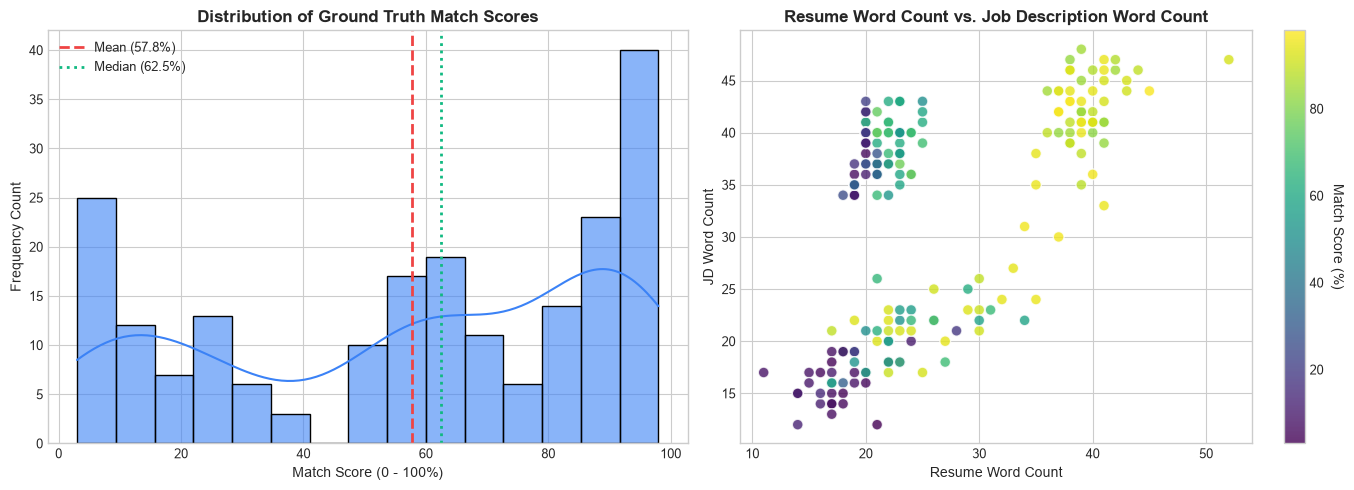

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Target Match Score Distribution
sns.histplot(df['match_score'], kde=True, ax=axes[0], color='#3B82F6', bins=15, alpha=0.6)
axes[0].axvline(df['match_score'].mean(), color='#EF4444', linestyle='--', linewidth=2, label=f"Mean ({df['match_score'].mean():.1f}%)")
axes[0].axvline(df['match_score'].median(), color='#10B981', linestyle=':', linewidth=2, label=f"Median ({df['match_score'].median():.1f}%)")
axes[0].set_title("Distribution of Ground Truth Match Scores", fontweight='bold')
axes[0].set_xlabel("Match Score (0 - 100%)")
axes[0].set_ylabel("Frequency Count")
axes[0].legend()

# Plot 2: Resume vs JD Word Count Scatter
scatter = axes[1].scatter(df['resume_word_count'], df['jd_word_count'], c=df['match_score'], cmap='viridis', s=60, alpha=0.8, edgecolors='w')
cbar = fig.colorbar(scatter, ax=axes[1])
cbar.set_label('Match Score (%)', rotation=270, labelpad=15)
axes[1].set_title("Resume Word Count vs. Job Description Word Count", fontweight='bold')
axes[1].set_xlabel("Resume Word Count")
axes[1].set_ylabel("JD Word Count")

plt.tight_layout()
plt.show()


## 🔤 3. NLP Preprocessing & Boundary-Aware Skill Extraction
We clean and normalize text while preserving specialized symbols (e.g., `c++`, `c#`, `.net`, `node.js`), then extract technical skills using boundary-safe regex against a taxonomy of 70+ technical competencies.


In [4]:
SKILLS_DATABASE = [
    "python", "java", "c++", "c#", "c", "javascript", "typescript", "go", "rust", "php", 
    "ruby", "swift", "kotlin", "r", "scala", "sql", "bash", "html", "html5", "css", "css3",
    "react", "next.js", "vue", "angular", "node.js", "express", "django", "fastapi", "flask", 
    "spring boot", "tailwind css", "bootstrap", "sass", "redux", "graphql", "rest api",
    "machine learning", "deep learning", "artificial intelligence", "nlp", "computer vision", 
    "generative ai", "llm", "transformers", "hugging face", "langchain", "llamaindex",
    "pytorch", "tensorflow", "keras", "scikit-learn", "pandas", "numpy", "scipy", "opencv", 
    "tableau", "power bi", "excel", "matplotlib", "seaborn",
    "aws", "azure", "gcp", "docker", "kubernetes", "git", "github", "gitlab", "linux", "ci/cd",
    "mysql", "postgresql", "mongodb", "redis", "sqlite", "snowflake", "bigquery", "pyspark", 
    "hadoop", "kafka", "airflow"
]

def clean_text(text: str) -> str:
    """Clean text while preserving relevant technical punctuation."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9+#.\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def extract_skills(text: str) -> set:
    """Boundary-aware technical skill extraction."""
    text_clean = " " + text.lower() + " "
    found = []
    sorted_skills = sorted(SKILLS_DATABASE, key=len, reverse=True)
    for skill in sorted_skills:
        escaped = re.escape(skill)
        if skill == "c":
            pattern = r'(?<![a-zA-Z0-9+#])c(?![a-zA-Z0-9+#])'
        elif skill == "r":
            pattern = r'(?<![a-zA-Z0-9])r(?![a-zA-Z0-9])'
        else:
            pattern = r'(?<![a-zA-Z0-9])' + escaped + r'(?![a-zA-Z0-9])'
        if re.search(pattern, text_clean):
            found.append(skill)
    return set(found)

# Apply preprocessing
df['resume_clean'] = df['resume_text'].apply(clean_text)
df['jd_clean'] = df['job_description'].apply(clean_text)

print("✅ Text cleaning and normalization completed.")
sample_skills = extract_skills(df.iloc[0]['resume_clean'])
print(f"Sample Extracted Skills: {sorted(list(sample_skills))[:8]}")


✅ Text cleaning and normalization completed.
Sample Extracted Skills: ['aws', 'machine learning', 'nlp', 'numpy', 'pandas', 'python', 'pytorch', 'r']


## ⚙️ 4. TF-IDF Vectorization & Multi-Feature Engineering
We transform text using sublinear TF-IDF with unigrams and bigrams, then compute 6 key predictive features:
1. **TF-IDF Cosine Similarity** ($\cos(\mathbf{u}, \mathbf{v})$)
2. **Jaccard Token Overlap** ($rac{|A \cap B|}{|A \cup B|}$)
3. **Job Description Token Coverage** ($rac{|A \cap B|}{|B|}$)
4. **Skill Match Ratio** ($rac{|	ext{Matched Skills}|}{|	ext{JD Skills}|}$)
5. **Count of Matched Skills**
6. **Document Length Ratio** ($rac{\min(L_A, L_B)}{\max(L_A, L_B)}$)


TF-IDF Vocabulary Size: 3778 n-grams


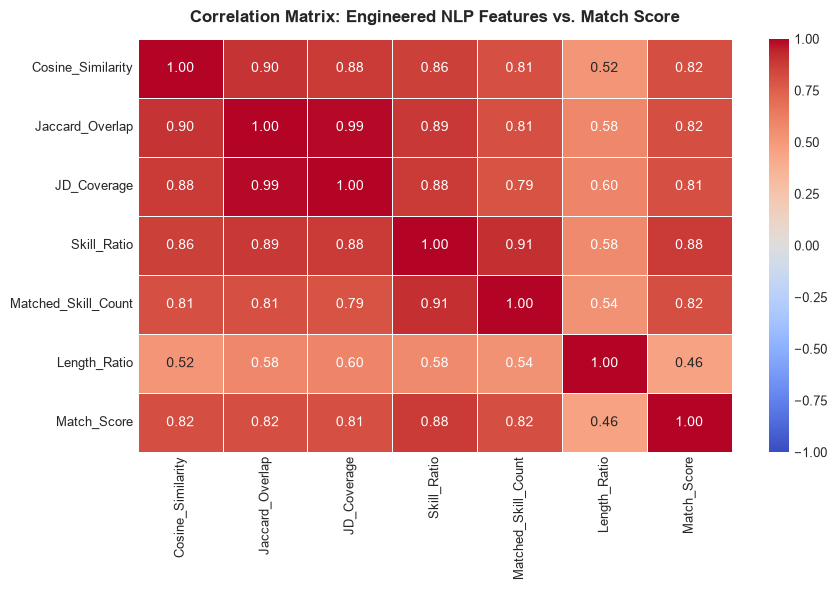

In [5]:
# 1. Fit TF-IDF Vectorizer on full corpus
corpus = pd.concat([df['resume_clean'], df['jd_clean']]).unique()
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True
)
vectorizer.fit(corpus)
print(f"TF-IDF Vocabulary Size: {len(vectorizer.vocabulary_)} n-grams")

# 2. Extract multi-dimensional feature matrix
def compute_feature_vector(resume_clean, jd_clean, vectorizer):
    vec_res = vectorizer.transform([resume_clean])
    vec_jd = vectorizer.transform([jd_clean])
    cos_sim = float(cosine_similarity(vec_res, vec_jd)[0][0])
    
    res_tokens = set(resume_clean.split())
    jd_tokens = set(jd_clean.split())
    intersection = len(res_tokens & jd_tokens)
    union = len(res_tokens | jd_tokens) if len(res_tokens | jd_tokens) > 0 else 1
    jaccard = intersection / union
    
    jd_cov = intersection / len(jd_tokens) if len(jd_tokens) > 0 else 0.0
    
    res_skills = extract_skills(resume_clean)
    jd_skills = extract_skills(jd_clean)
    matched_skills = res_skills & jd_skills
    skill_ratio = len(matched_skills) / len(jd_skills) if len(jd_skills) > 0 else 0.0
    
    len_ratio = min(len(resume_clean), len(jd_clean)) / max(len(resume_clean), len(jd_clean), 1)
    
    return [cos_sim, jaccard, jd_cov, skill_ratio, len(matched_skills), len_ratio]

feature_names = ['Cosine_Similarity', 'Jaccard_Overlap', 'JD_Coverage', 'Skill_Ratio', 'Matched_Skill_Count', 'Length_Ratio']
X = np.array([compute_feature_vector(r, j, vectorizer) for r, j in zip(df['resume_clean'], df['jd_clean'])])
y = df['match_score'].values.astype(float)

features_df = pd.DataFrame(X, columns=feature_names)
features_df['Match_Score'] = y

# Visualize Feature Correlation Heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(features_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix: Engineered NLP Features vs. Match Score", fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


## 🤖 5. Supervised Machine Learning Model Training & Comparison
We partition the dataset (80% Train, 20% Test) and evaluate three distinct regression architectures:
- **Random Forest Regressor** (Ensemble of decision trees capturing non-linear interactions)
- **Gradient Boosting Regressor** (Sequential gradient boosting for loss minimization)
- **Ridge Regression** ($L_2$ regularized linear model baseline)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

models = {
    "Random Forest": RandomForestRegressor(n_estimators=150, max_depth=8, min_samples_split=3, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42),
    "Ridge Regression": Ridge(alpha=1.0)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    y_pred_train = np.clip(model.predict(X_train), 0, 100)
    y_pred_test = np.clip(model.predict(X_test), 0, 100)
    
    mae_tr, mae_te = mean_absolute_error(y_train, y_pred_train), mean_absolute_error(y_test, y_pred_test)
    rmse_tr, rmse_te = np.sqrt(mean_squared_error(y_train, y_pred_train)), np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_tr, r2_te = r2_score(y_train, y_pred_train), r2_score(y_test, y_pred_test)
    
    results.append({
        "Model": name,
        "Train MAE": mae_tr,
        "Test MAE": mae_te,
        "Train RMSE": rmse_tr,
        "Test RMSE": rmse_te,
        "Train R²": r2_tr,
        "Test R²": r2_te
    })

res_df = pd.DataFrame(results).round(3)
display(res_df)

best_model = trained_models["Random Forest"]


,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Random Forest,2.940,8.393,3.935,13.272,0.985,0.817
1,Gradient Boosting,1.330,9.687,1.694,15.814,0.997,0.741
2,Ridge Regression,11.203,12.922,14.058,16.377,0.810,0.722


## 📈 6. Comprehensive Predictive Evaluation Graphs
We generate 4 high-resolution diagnostic graphs to evaluate the predictive power and calibration of our trained model.


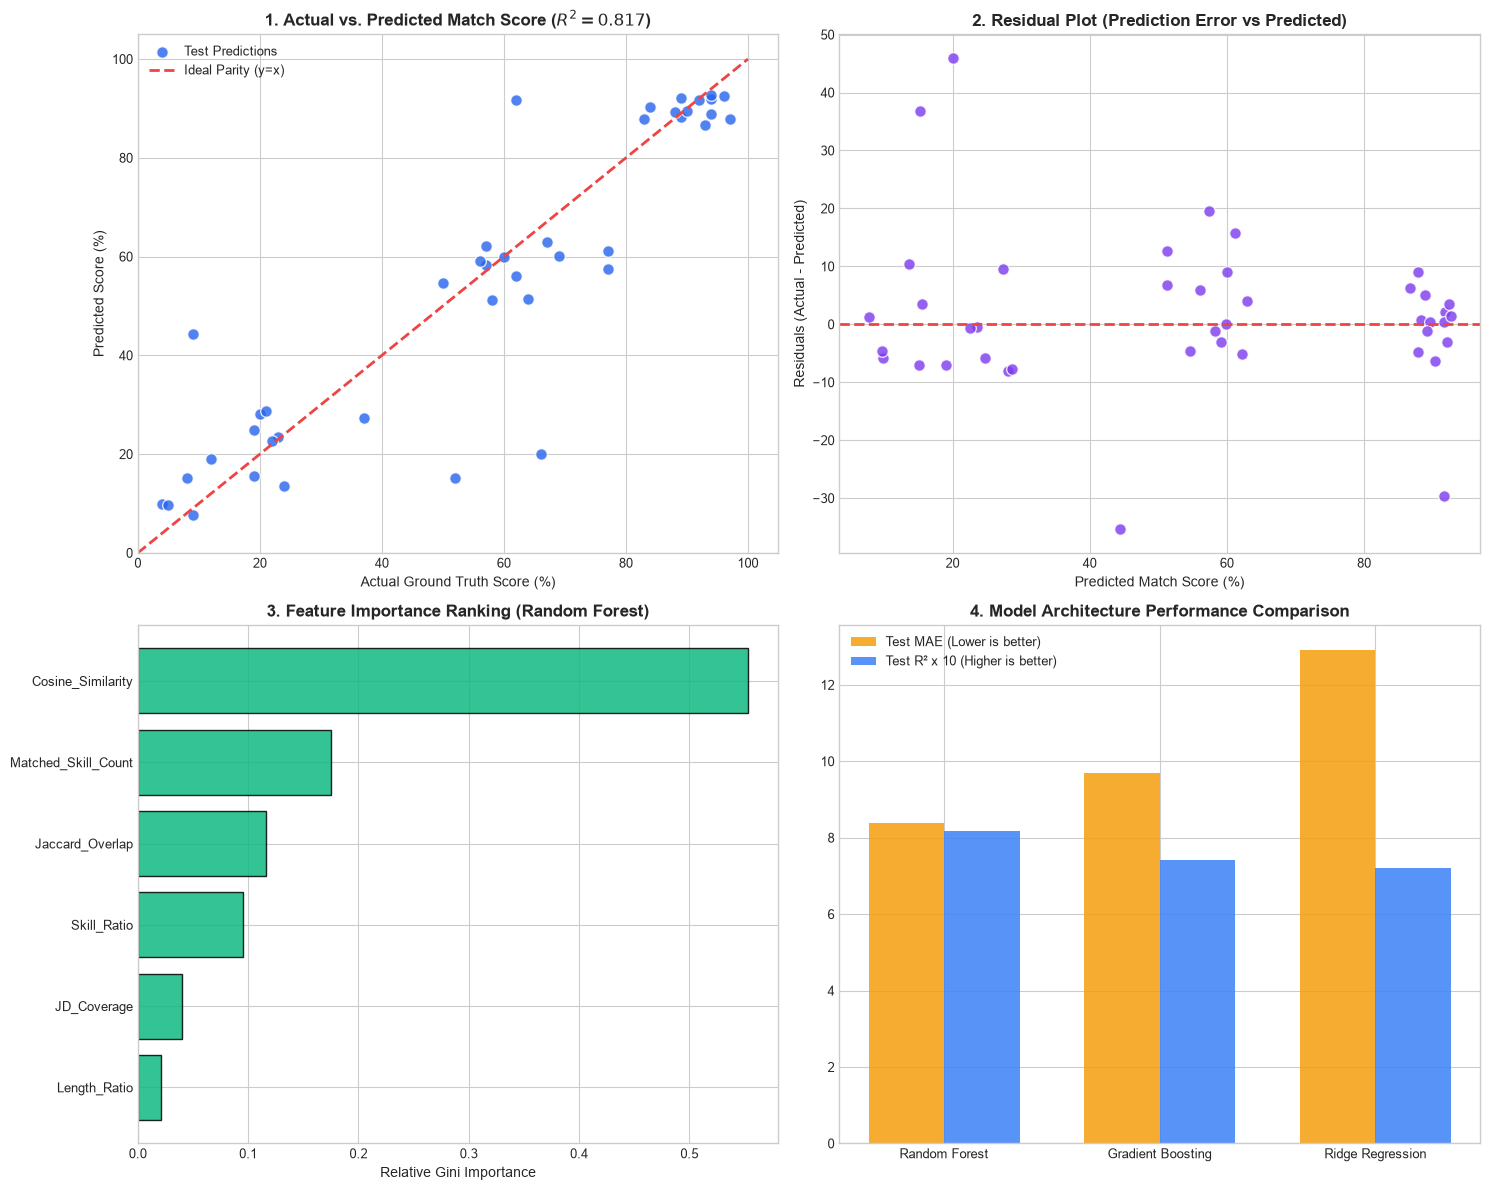

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

y_pred_test = np.clip(best_model.predict(X_test), 0, 100)
residuals = y_test - y_pred_test

# 1. Actual vs Predicted Match Score
axes[0, 0].scatter(y_test, y_pred_test, color='#2563EB', s=70, alpha=0.8, edgecolors='w', label='Test Predictions')
axes[0, 0].plot([0, 100], [0, 100], color='#EF4444', linestyle='--', linewidth=2, label='Ideal Parity (y=x)')
axes[0, 0].set_title(f"1. Actual vs. Predicted Match Score ($R^2 = {r2_score(y_test, y_pred_test):.3f}$)", fontweight='bold')
axes[0, 0].set_xlabel("Actual Ground Truth Score (%)")
axes[0, 0].set_ylabel("Predicted Score (%)")
axes[0, 0].set_xlim(0, 105)
axes[0, 0].set_ylim(0, 105)
axes[0, 0].legend()

# 2. Residual Analysis Plot
axes[0, 1].scatter(y_pred_test, residuals, color='#7C3AED', s=70, alpha=0.8, edgecolors='w')
axes[0, 1].axhline(0, color='#EF4444', linestyle='--', linewidth=2)
axes[0, 1].set_title("2. Residual Plot (Prediction Error vs Predicted)", fontweight='bold')
axes[0, 1].set_xlabel("Predicted Match Score (%)")
axes[0, 1].set_ylabel("Residuals (Actual - Predicted)")

# 3. Random Forest Feature Importance
importances = best_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=True)
axes[1, 0].barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='#10B981', alpha=0.85, edgecolor='black')
axes[1, 0].set_title("3. Feature Importance Ranking (Random Forest)", fontweight='bold')
axes[1, 0].set_xlabel("Relative Gini Importance")

# 4. Model Comparison Metrics (Test MAE & R²)
model_names = res_df['Model']
x_pos = np.arange(len(model_names))
w = 0.35
axes[1, 1].bar(x_pos - w/2, res_df['Test MAE'], width=w, label='Test MAE (Lower is better)', color='#F59E0B', alpha=0.85)
axes[1, 1].bar(x_pos + w/2, res_df['Test R²'] * 10, width=w, label='Test R² x 10 (Higher is better)', color='#3B82F6', alpha=0.85)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(model_names)
axes[1, 1].set_title("4. Model Architecture Performance Comparison", fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## 🕸️ 7. Graph-Theoretic Resume Matching & Bipartite Knowledge Networks
We formulate candidate-job alignment as a **Bipartite Graph** $G = (V_{\text{candidate}}, V_{\text{job}}, E)$ using `NetworkX`:
- **Nodes**:
  - $V_{\text{candidate}}$: Candidate profile and possessed technical competencies.
  - $V_{\text{job}}$: Target role and required technical prerequisite skills.
- **Node Categorization**:
  - 🟢 **Matched Skills (Emerald)**: Present in both Candidate and Job.
  - 🔴 **Missing Skills (Crimson)**: Required by Job, absent in Candidate resume.
  - 🔵 **Extra Skills (Sky Blue)**: Additional candidate competencies.
- **Graph Metrics**:
  - **Skill Jaccard Density**: $\frac{|V_{\text{matched}}|}{|V_{\text{candidate}} \cup V_{\text{job}}|}$
  - **Job Skill Coverage**: $\frac{|V_{\text{matched}}|}{|V_{\text{job skills}}|}$


In [8]:
def build_skill_bipartite_graph(resume_text, jd_text):
    """
    Constructs a NetworkX Bipartite Knowledge Graph between Candidate Skills and Job Requirements.
    """
    res_clean = clean_text(resume_text)
    jd_clean = clean_text(jd_text)
    
    res_skills = extract_skills(res_clean)
    jd_skills = extract_skills(jd_clean)
    
    matched = res_skills & jd_skills
    missing = jd_skills - res_skills
    extra = res_skills - jd_skills
    
    G = nx.Graph()
    
    # Core Entity Nodes
    G.add_node("Candidate Resume", node_type="entity_resume", layer=0)
    G.add_node("Job Description", node_type="entity_jd", layer=2)
    
    # Add Skill Nodes
    for s in matched:
        G.add_node(s.title(), node_type="matched", layer=1)
        G.add_edge("Candidate Resume", s.title(), weight=1.0, relation="possesses")
        G.add_edge("Job Description", s.title(), weight=1.0, relation="requires")
        
    for s in missing:
        G.add_node(s.title(), node_type="missing", layer=2)
        G.add_edge("Job Description", s.title(), weight=0.8, relation="requires_missing")
        
    for s in extra:
        G.add_node(s.title(), node_type="extra", layer=0)
        G.add_edge("Candidate Resume", s.title(), weight=0.8, relation="extra_skill")
        
    metrics = {
        "matched_count": len(matched),
        "missing_count": len(missing),
        "extra_count": len(extra),
        "total_jd_skills": len(jd_skills),
        "coverage_ratio": (len(matched) / len(jd_skills)) if len(jd_skills) > 0 else 1.0,
        "graph_density": nx.density(G),
        "node_count": G.number_of_nodes(),
        "edge_count": G.number_of_edges()
    }
    
    return G, metrics, matched, missing, extra

print("✅ Bipartite Graph constructor ready.")


✅ Bipartite Graph constructor ready.


## 🚀 8. Dual-Graph End-to-End Prediction Visualizer Pipeline
We create an end-to-end function `predict_and_plot_resume_match` that takes raw resume text and job description, predicts the match score, and plots:
1. **The Bipartite Knowledge Match Graph** (Network layout)
2. **The Multi-Dimensional Competency Radar Chart** (Cosine Sim, Skill Ratio, Keyword Coverage, Jaccard Index, Length Alignment)


In [9]:
def predict_and_plot_resume_match(resume_text, jd_text, model, vectorizer, scenario_title="Candidate Assessment"):
    """
    Predicts match score and displays dual graph visualization:
    1. Bipartite Skill Network
    2. Multivariate Competency Radar
    """
    # 1. Feature computation & Prediction
    res_clean = clean_text(resume_text)
    jd_clean = clean_text(jd_text)
    feats = compute_feature_vector(res_clean, jd_clean, vectorizer)
    
    pred_score = float(np.clip(model.predict([feats])[0], 0, 100))
    cos_score = round(feats[0] * 100, 1)
    jaccard_score = round(feats[1] * 100, 1)
    jd_cov_score = round(feats[2] * 100, 1)
    skill_ratio_score = round(feats[3] * 100, 1)
    
    # 2. Build Bipartite Graph
    G, metrics, matched, missing, extra = build_skill_bipartite_graph(resume_text, jd_text)
    
    # 3. Plot Dual-Graph Dashboard
    fig = plt.figure(figsize=(16, 7))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.25, 0.95])
    
    ax_graph = fig.add_subplot(gs[0, 0])
    ax_radar = fig.add_subplot(gs[0, 1], polar=True)
    
    # --- PANEL 1: Structured Multi-Column Network Graph ---
    pos = {}
    pos["Candidate Resume"] = np.array([0.25, 0.5])
    pos["Job Description"] = np.array([0.75, 0.5])
    
    matched_disp = list(matched)[:10]
    n_mat = len(matched_disp)
    for i, s in enumerate(matched_disp):
        y_c = 0.15 + (0.7 * (i / max(n_mat - 1, 1))) if n_mat > 1 else 0.5
        pos[s.title()] = np.array([0.50, y_c])
        
    extra_disp = list(extra)[:6]
    n_ext = len(extra_disp)
    for i, s in enumerate(extra_disp):
        y_c = 0.2 + (0.6 * (i / max(n_ext - 1, 1))) if n_ext > 1 else 0.5
        pos[s.title()] = np.array([0.02, y_c])
        
    miss_disp = list(missing)[:8]
    n_mis = len(miss_disp)
    for i, s in enumerate(miss_disp):
        y_c = 0.15 + (0.7 * (i / max(n_mis - 1, 1))) if n_mis > 1 else 0.5
        pos[s.title()] = np.array([0.98, y_c])
        
    # Column highlights
    ax_graph.axvspan(-0.06, 0.12, color='#0EA5E9', alpha=0.04, lw=0)
    ax_graph.axvspan(0.40, 0.60, color='#10B981', alpha=0.06, lw=0)
    ax_graph.axvspan(0.88, 1.06, color='#EF4444', alpha=0.04, lw=0)
    
    # Headers
    ax_graph.text(0.02, 0.96, f"Extras ({len(extra)})", ha='center', va='center', fontsize=9, fontweight='bold', color='#0284C7',
                  bbox=dict(boxstyle="round,pad=0.25", facecolor='#E0F2FE', edgecolor='#BAE6FD', alpha=0.9))
    ax_graph.text(0.50, 0.96, f"✓ Matched ({len(matched)})", ha='center', va='center', fontsize=9.5, fontweight='bold', color='#059669',
                  bbox=dict(boxstyle="round,pad=0.25", facecolor='#D1FAE5', edgecolor='#A7F3D0', alpha=0.9))
    ax_graph.text(0.98, 0.96, f"✗ Missing ({len(missing)})", ha='center', va='center', fontsize=9, fontweight='bold', color='#DC2626',
                  bbox=dict(boxstyle="round,pad=0.25", facecolor='#FEE2E2', edgecolor='#FECACA', alpha=0.9))
    
    # Draw Edges for displayed nodes
    for u, v, data in G.edges(data=True):
        if u in pos and v in pos:
            rel = data.get('relation', '')
            p1, p2 = pos[u], pos[v]
            if rel in ('possesses', 'requires'):
                ax_graph.plot([p1[0], p2[0]], [p1[1], p2[1]], color='#10B981', lw=2.0, alpha=0.75, zorder=1)
            elif rel == 'requires_missing':
                ax_graph.plot([p1[0], p2[0]], [p1[1], p2[1]], color='#EF4444', lw=1.5, linestyle='--', alpha=0.7, zorder=1)
            else:
                ax_graph.plot([p1[0], p2[0]], [p1[1], p2[1]], color='#0EA5E9', lw=1.5, linestyle=':', alpha=0.7, zorder=1)
                
    # Draw Nodes and Labels
    for node, p in pos.items():
        data = G.nodes[node] if node in G.nodes else {}
        ntype = data.get('node_type', '')
        if ntype == 'entity_resume':
            c, s, b = '#2563EB', 2400, '#1D4ED8'
        elif ntype == 'entity_jd':
            c, s, b = '#7C3AED', 2400, '#6D28D9'
        elif ntype == 'matched':
            c, s, b = '#10B981', 1000, '#047857'
        elif ntype == 'missing':
            c, s, b = '#EF4444', 850, '#B91C1C'
        elif ntype == 'extra':
            c, s, b = '#0EA5E9', 850, '#0369A1'
        else:
            c, s, b = '#94A3B8', 600, '#64748B'
            
        ax_graph.scatter(p[0], p[1], s=s, c=c, edgecolors=b, linewidths=1.8, alpha=0.95, zorder=2)
        is_entity = node in ("Candidate Resume", "Job Description")
        font_c = '#FFFFFF' if is_entity else '#0F172A'
        if is_entity:
            ax_graph.text(p[0], p[1], node, ha='center', va='center', color=font_c, fontsize=8.5, fontweight='bold', zorder=3)
        else:
            ax_graph.text(p[0], p[1], node, ha='center', va='center', color=font_c, fontsize=8.0, fontweight='bold', zorder=3,
                          bbox=dict(boxstyle="round,pad=0.2", facecolor='#FFFFFF', edgecolor=b, alpha=0.9, lw=1.0))
                          
    ax_graph.set_xlim(-0.10, 1.10)
    ax_graph.set_ylim(0.04, 1.06)
    ax_graph.set_title(f"Bipartite Skill & Knowledge Graph\nCoverage: {metrics['coverage_ratio']*100:.1f}% ({len(matched)}/{metrics['total_jd_skills']} Skills)", fontweight='bold')
    ax_graph.axis('off')
    
    # --- PANEL 2: Multivariate Radar Chart ---
    categories = ['Cosine Similarity', 'Skill Ratio', 'JD Coverage', 'Jaccard Overlap', 'Length Alignment']
    values = [cos_score, skill_ratio_score, jd_cov_score, jaccard_score, feats[5]*100]
    values += values[:1]
    
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]
    
    ax_radar.plot(angles, values, color='#2563EB', linewidth=2.5, linestyle='solid', zorder=3)
    ax_radar.fill(angles, values, color='#3B82F6', alpha=0.35, zorder=2)
    ax_radar.scatter(angles[:-1], values[:-1], color='#1D4ED8', s=50, edgecolors='white', linewidths=1.5, zorder=4)
    
    for ang, val in zip(angles[:-1], values[:-1]):
        ax_radar.text(ang, min(val + 8, 105), f"{val:.1f}%", ha='center', va='center', fontsize=8.0, fontweight='bold', color='#1E40AF',
                      bbox=dict(boxstyle="round,pad=0.2", facecolor='#EFF6FF', edgecolor='#93C5FD', alpha=0.9, lw=0.8))
                      
    ax_radar.set_xticks(angles[:-1])
    ax_radar.set_xticklabels(categories, fontweight='bold', size=9)
    ax_radar.set_ylim(0, 105)
    ax_radar.set_yticks([20, 40, 60, 80, 100])
    ax_radar.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], color='#64748B', size=8)
    
    tier = "🌟 EXCELLENT MATCH" if pred_score >= 80 else ("👍 GOOD MATCH" if pred_score >= 60 else ("⚠️ MODERATE MATCH" if pred_score >= 40 else "❌ LOW MATCH"))
    ax_radar.set_title(f"Competency Alignment Radar\nPredicted Match: {pred_score:.1f}% ({tier})", fontweight='bold', pad=20)
    
    plt.suptitle(f"📊 AI Resume Matcher Evaluation — {scenario_title}", fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print formatted scorecard
    print("=" * 70)
    print(f"📋 ASSESSMENT SCORECARD — {scenario_title.upper()}")
    print("=" * 70)
    print(f"• Predicted ML Match Score : {pred_score:.2f}%")
    print(f"• NLP Cosine Similarity    : {cos_score:.2f}%")
    print(f"• Skill Match Coverage     : {skill_ratio_score:.2f}% ({len(matched)} / {metrics['total_jd_skills']} JD skills)")
    print(f"• Matched Skills           : {', '.join(sorted(list(matched))) if matched else 'None'}")
    print(f"• Missing Skills           : {', '.join(sorted(list(missing))) if missing else 'None'}")
    print(f"• Extra Strengths          : {', '.join(sorted(list(extra))) if extra else 'None'}")
    print("=" * 70 + "\n")


## 🧪 9. Demonstration on Real-World Case Studies
We test our graph prediction engine across 3 diverse hiring scenarios:
1. **Scenario A**: High Match — Senior Python & Backend Engineer
2. **Scenario B**: Medium Match — Frontend Developer applying for Full-Stack
3. **Scenario C**: Low Match — Graphic Designer applying for AI Engineer


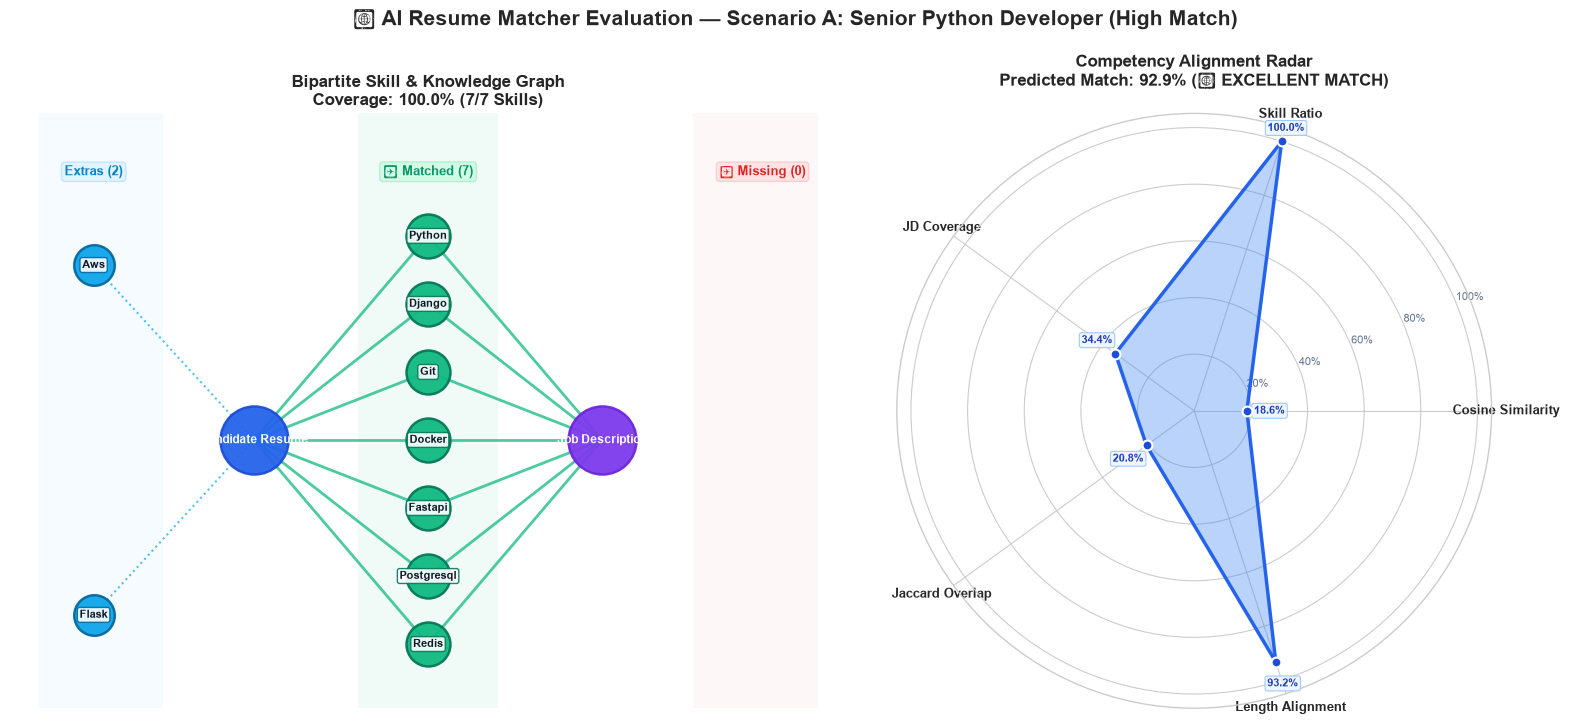

📋 ASSESSMENT SCORECARD — SCENARIO A: SENIOR PYTHON DEVELOPER (HIGH MATCH)
• Predicted ML Match Score : 92.88%
• NLP Cosine Similarity    : 18.60%
• Skill Match Coverage     : 100.00% (7 / 7 JD skills)
• Matched Skills           : django, docker, fastapi, git, postgresql, python, redis
• Missing Skills           : None
• Extra Strengths          : aws, flask



In [10]:
# Scenario A: High Match
resume_high = (
    "Senior Python Developer with 5 years experience in building scalable REST APIs using Python, "
    "Django, FastAPI, Flask, PostgreSQL, Docker, Redis, Celery, and Git. Proficient in Pytest, "
    "CI/CD microservices architecture, and AWS EC2 cloud deployment."
)
jd_high = (
    "We are seeking an experienced Python Developer to build scalable backend services and RESTful APIs. "
    "Must have strong skills in Python, Django or FastAPI, PostgreSQL, Redis, Celery, Docker, unit testing, "
    "and Git version control."
)

predict_and_plot_resume_match(resume_high, jd_high, best_model, vectorizer, scenario_title="Scenario A: Senior Python Developer (High Match)")


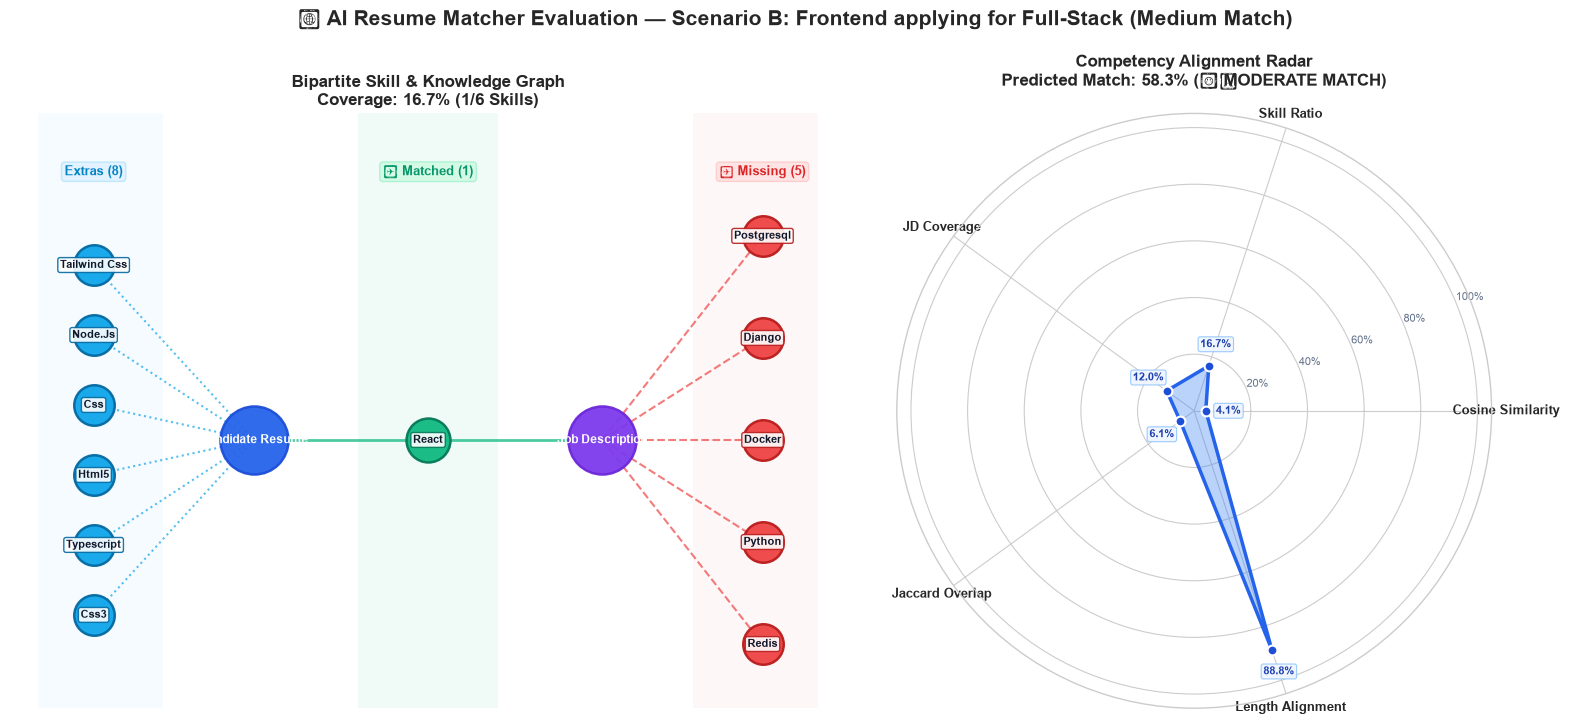

📋 ASSESSMENT SCORECARD — SCENARIO B: FRONTEND APPLYING FOR FULL-STACK (MEDIUM MATCH)
• Predicted ML Match Score : 58.34%
• NLP Cosine Similarity    : 4.10%
• Skill Match Coverage     : 16.70% (1 / 6 JD skills)
• Matched Skills           : react
• Missing Skills           : django, docker, postgresql, python, redis
• Extra Strengths          : css, css3, html5, javascript, node.js, redux, tailwind css, typescript



In [11]:
# Scenario B: Medium Match
resume_med = (
    "Frontend Web Developer with 3 years of experience in React, JavaScript, TypeScript, HTML5, "
    "CSS3, Tailwind CSS, Redux, and basic Node.js backend. Built single page applications and responsive UI."
)
jd_med = (
    "Looking for a Full Stack Software Engineer to build complex backend microservices in Python, "
    "Django, PostgreSQL, Docker, Redis caching, CI/CD pipelines, and React frontend."
)

predict_and_plot_resume_match(resume_med, jd_med, best_model, vectorizer, scenario_title="Scenario B: Frontend applying for Full-Stack (Medium Match)")


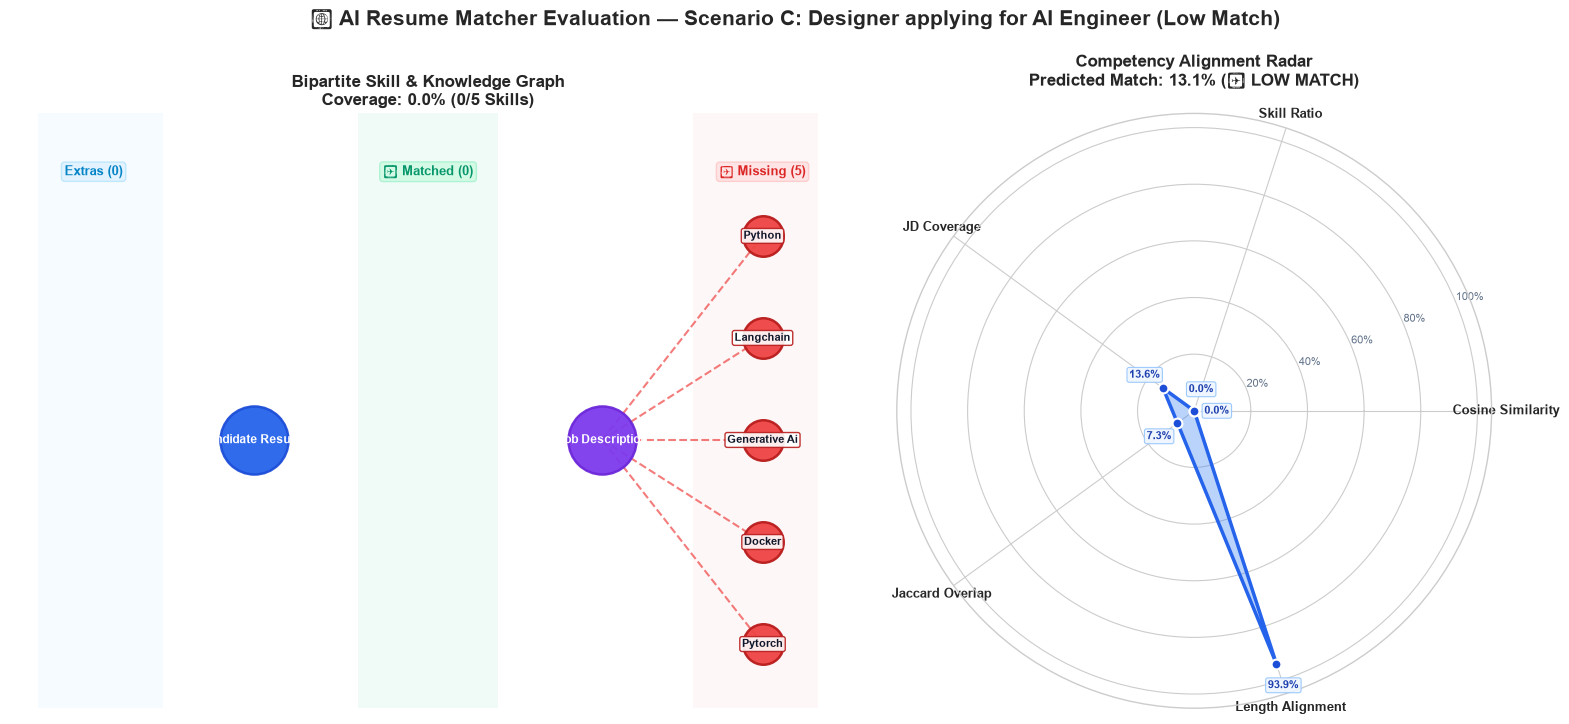

📋 ASSESSMENT SCORECARD — SCENARIO C: DESIGNER APPLYING FOR AI ENGINEER (LOW MATCH)
• Predicted ML Match Score : 13.14%
• NLP Cosine Similarity    : 0.00%
• Skill Match Coverage     : 0.00% (0 / 5 JD skills)
• Matched Skills           : None
• Missing Skills           : docker, generative ai, langchain, python, pytorch
• Extra Strengths          : None



In [12]:
# Scenario C: Low Match
resume_low = (
    "Graphic Designer with expert proficiency in Adobe Photoshop, Illustrator, Figma, UI/UX wireframing, "
    "brand identity design, typography, and creative digital media editing."
)
jd_low = (
    "We are seeking an AI Engineer with expertise in Generative AI, LLMs, LangChain, RAG architecture, "
    "vector search, Python, PyTorch, and model deployment in Docker."
)

predict_and_plot_resume_match(resume_low, jd_low, best_model, vectorizer, scenario_title="Scenario C: Designer applying for AI Engineer (Low Match)")


## 💾 10. Model Artifact Serialization & Conclusion
We persist the trained `RandomForestRegressor` and fitted `TfidfVectorizer` into the `model/` directory for seamless integration with the Streamlit web application.


In [13]:
model_dir = os.path.join(os.getcwd(), 'model')
if not os.path.exists(model_dir):
    model_dir = '../model'
os.makedirs(model_dir, exist_ok=True)

model_export_path = os.path.join(model_dir, 'regression_model.pkl')
vectorizer_export_path = os.path.join(model_dir, 'tfidf_vectorizer.pkl')

joblib.dump(best_model, model_export_path)
joblib.dump(vectorizer, vectorizer_export_path)

print("=" * 60)
print("✅ MODEL ARTIFACTS EXPORTED SUCCESSFULLY")
print(f"• Random Forest Regressor : {model_export_path}")
print(f"• TF-IDF Vectorizer       : {vectorizer_export_path}")
print("=" * 60)


✅ MODEL ARTIFACTS EXPORTED SUCCESSFULLY
• Random Forest Regressor : /Users/arifkhadim/Documents/AI_Resume_Matcher/model/regression_model.pkl
• TF-IDF Vectorizer       : /Users/arifkhadim/Documents/AI_Resume_Matcher/model/tfidf_vectorizer.pkl
